# [Kaggle 닷컴](https://www.kaggle.com/datasets/victoriayuno/titaniccsv)의 타이타닉 생존자 데이터 분석

In [17]:
import pandas as pd # pandas 패키지를 pd라는 별명으로 불러옴
file='C:/Temp/Titanic.csv' # 파일 위치 지정
df=pd.read_csv(file) # csv 파일을 읽어서 DataFrame으로 저장 해줌

# 불필요한 컬럼 제거 하기
df.drop(columns=['PassengerId','Name','Ticket'],inplace=True)

# missing data 만들어 넣기
df['Age'].fillna(df['Age'].mean(),inplace=True)
df['Cabin'].fillna('N',inplace=True)
df['Embarked'].fillna('N',inplace=True)

# 문자열 간단히 하기
df['Cabin']=df['Cabin'].str[:1] # 첫번째 문자열 선택

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     891 non-null    object 
 8   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [18]:
df.Sex.value_counts()

male      577
female    314
Name: Sex, dtype: int64

In [19]:
df.Embarked.value_counts()

S    644
C    168
Q     77
N      2
Name: Embarked, dtype: int64

In [20]:
df.Cabin.value_counts()

N    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: Cabin, dtype: int64

In [21]:
from sklearn.preprocessing import LabelEncoder
E=['개','돼지','고양이']
LE=LabelEncoder() # LabelEncoder 객체 만들기

# LabelEncoder로 E 문자열을 숫자로 매핑시키기
# LE 객체 아래 fit이나 fit_transform으로 1:1 규칙 생성
LE.fit_transform(E)

array([0, 2, 1], dtype=int64)

In [22]:
# 이미 만들어진 규칙아래에서 특정단어를 숫자로 변환
LE.transform(['고양이'])

array([1])

In [23]:
LE.transform(['돼지'])

array([2])

In [24]:
LE.transform(['개'])

array([0])

In [25]:
# inverse_transform()을 사용하여 원래 텍스트 값 복원가능
LE.inverse_transform([0])

array(['개'], dtype='<U3')

In [26]:
# 문자열을 숫자열로 변환시키기
from sklearn.preprocessing import LabelEncoder
LE=LabelEncoder() # 객체 설정
df['Sex']=LE.fit_transform(df.Sex) # 'Sex'칼럼을 숫자로 매칭
df['Cabin']=LE.fit_transform(df.Cabin) # 'Cabin'칼럼을 숫자로 매칭
df['Embarked']=LE.fit_transform(df.Embarked) # 'Embarked'칼럼을 숫자로 매칭

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int32  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     891 non-null    int32  
 8   Embarked  891 non-null    int32  
dtypes: float64(2), int32(3), int64(4)
memory usage: 52.3 KB


In [27]:
# 종속변수와 독립변수 만들기
Y=df.Survived
X=df.drop(columns='Survived')

# train, test data split
from sklearn.model_selection import train_test_split
# 무작위로 X,Y 데이터를 나눈다. 
# stratify=Y는 Y의 값의 원래 비율이 유지되도록 하면서 데이터를 분류하게끔 한다. 
X_train, X_test, Y_train, Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y)

In [28]:
# 계층화된(stratified) Y_train, Y_test 값의 비율 살펴보기
# narmalize=True로 설정하면 비율로 값을 리턴해 준다. 
Y.value_counts(normalize=True),Y_train.value_counts(normalize=True),Y_test.value_counts(normalize=True)

(0    0.616162
 1    0.383838
 Name: Survived, dtype: float64,
 0    0.616573
 1    0.383427
 Name: Survived, dtype: float64,
 0    0.614525
 1    0.385475
 Name: Survived, dtype: float64)

In [68]:
# ANN 모형 구현
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from sklearn.metrics import  accuracy_score,confusion_matrix
import numpy as np

# 신경망 모델 구축
model = Sequential()

# 레이어 등록
model.add(Dense(units=64, activation='relu',input_shape=(8,)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))

# 모델 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])

# 모델 학습
history=model.fit(X_train, Y_train, epochs=100,
                  verbose=0,validation_split=0.2)

# 모델 예측과 혼동행렬
pred=model.predict(X_test)
Yp=np.round(pred)
accuracy_score(Y_test,Yp)

6/6 [==============================] - 0s 4ms/step


0.7541899441340782

Text(67.25, 0.5, 'True Label')

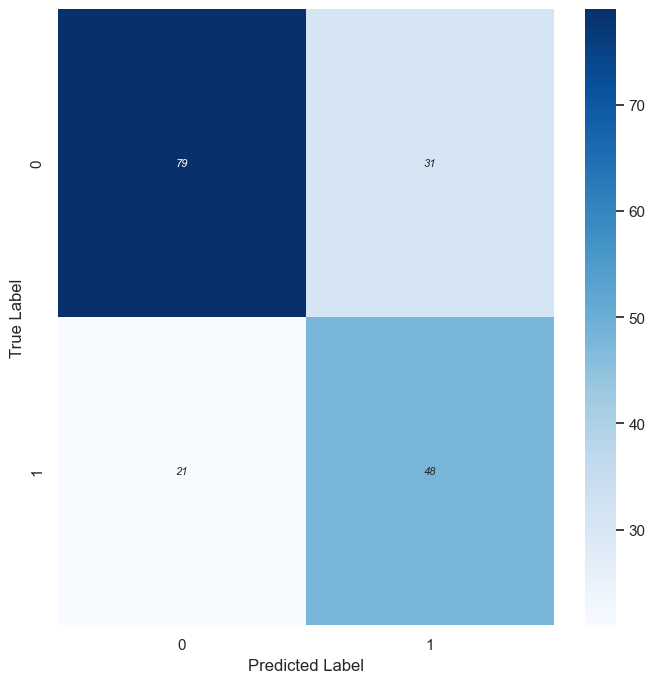

In [67]:
conf_matrix=confusion_matrix(Y_test,Yp)

sns.set(style='white')

plt.figure(figsize=(8,8))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d',cbar=True,
            annot_kws={"size": 8, "weight": "normal", "style": "italic"})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

In [70]:
# 데이터 학습 및 예측
from sklearn.ensemble import RandomForestClassifier
RFC=RandomForestClassifier() # 학습기 객체 설정

RFC.fit(X_train,Y_train) #데이터 학습진행
Y_predicted=RFC.predict(X_test) # X_test 값을 바탕으로 예측값 만들기

# 데이터 학습 효과 분석
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print('정확도: ', accuracy_score(Y_test,Y_predicted),'\n')
print('confusion matrix\n', confusion_matrix(Y_test,Y_predicted),'\n')
print('classification reprort\n',classification_report(Y_test,Y_predicted))

정확도:  0.7653631284916201 

confusion matrix
 [[90 20]
 [22 47]] 

classification reprort
               precision    recall  f1-score   support

           0       0.80      0.82      0.81       110
           1       0.70      0.68      0.69        69

    accuracy                           0.77       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.77      0.76       179



# 텍스트 마이닝의 시작

In [16]:
# 텍스트 분석시 encoding 확인 필요
import chardet
file='C:/Temp/korean_news.txt'
# 'rb'에서 r은 읽기모드, b는 바이너리 형식
with open(file,'rb') as f:
    result=chardet.detect(f.read())
print(result)

{'encoding': 'utf-8', 'confidence': 0.99, 'language': ''}


In [17]:
# 자원의 획득
f = open(file,'rb')

# 자원의 사용
text = f.read()
result=chardet.detect(f.read())
print(result)

# 자원의 반납
f.close()

{'encoding': None, 'confidence': 0.0, 'language': None}


In [18]:
# 파일 열기 (읽기 모드로)
with open(file, 'r', encoding='utf-8') as ff:
    # 파일 내용 읽기
    file_content = ff.read()

    # 파일 내용 출력
    print(file_content)

대통령에 취임한 지 어느덧 20개월, 임기 3분의 1이 지났지만 윤석열 대통령이 정식 기자회견에 나선 건 취임 100일 때가 유일합니다.

윤 대통령은 53분 동안, 모두발언에 이어 내·외신 기자들에게 질문 열두 개를 받았고, 특히 파격 자체였던 출근길 약식회견에는 강한 애정과 자부심을 드러냈습니다.

[윤석열 / 대통령(지난해 8월) : 대통령직 수행 과정이 국민에게 투명하게 드러나고 날 선 비판, 다양한 지적을 받아야 한다고 저는 생각합니다.]

'권력형 침묵'을 깨고 매일 아침 질문받는 대통령, 용산으로 온 이유라던 '도어 스테핑'은 지난해 11월 잠정 중단됐고,

[윤석열 / 대통령 (지난해 11월) : (동맹 관계를) 가짜뉴스로 이간질하려고 아주 악의적인 행태를 보였기 때문에….]

취임 후 194일 동안 예순한 차례, 총 3시간 23분의 출근길 문답은 이제 역사의 한 페이지가 됐습니다.

이후 윤 대통령은 해외 일정 때 몇 차례를 빼고는 취재진 질문을 받은 적이 없습니다.

올해 10분짜리 신년사를 통해 노동·교육·연금 '3대 개혁'과 수출 증진이라는 화두를 던졌을 뿐, 한해 정국 구상은 조선일보와 단독 인터뷰에서만 풀어놨습니다.

내년에는 새해 기자회견이 열릴까, 일단 선택지에는 있습니다.

대통령실 관계자들은 YTN에 윤 대통령 특유의 솔직함과 담백한 카리스마로 여러 현안을 정면돌파할 수 있다고 기대했습니다.

대통령실과 내각, 국민의힘까지 사실상 '윤석열 정부 2기 체제'가 출범한 만큼 국정 청사진을 밝힐 좋은 계기라고 밝혔습니다.

하지만 김건희 여사 명품 수수 논란부터 검찰 중심 회전문 인사, 윤심 공천 우려 등 부담스러운 이슈가 적지 않습니다.

윤 대통령은 일단 새해 첫날 발표할 신년사 집필은 시작했습니다.

나아가 직접 소통의 필요성도 절감하고 있다는데, 윤석열 정부 성패를 좌우할 총선의 해, 어떻게 민심과 교감할지 지금 이 시점, 모든 가능성은 열려있습니다.



In [19]:
file_content.replace('\n','')

"대통령에 취임한 지 어느덧 20개월, 임기 3분의 1이 지났지만 윤석열 대통령이 정식 기자회견에 나선 건 취임 100일 때가 유일합니다.윤 대통령은 53분 동안, 모두발언에 이어 내·외신 기자들에게 질문 열두 개를 받았고, 특히 파격 자체였던 출근길 약식회견에는 강한 애정과 자부심을 드러냈습니다.[윤석열 / 대통령(지난해 8월) : 대통령직 수행 과정이 국민에게 투명하게 드러나고 날 선 비판, 다양한 지적을 받아야 한다고 저는 생각합니다.]'권력형 침묵'을 깨고 매일 아침 질문받는 대통령, 용산으로 온 이유라던 '도어 스테핑'은 지난해 11월 잠정 중단됐고,[윤석열 / 대통령 (지난해 11월) : (동맹 관계를) 가짜뉴스로 이간질하려고 아주 악의적인 행태를 보였기 때문에….]취임 후 194일 동안 예순한 차례, 총 3시간 23분의 출근길 문답은 이제 역사의 한 페이지가 됐습니다.이후 윤 대통령은 해외 일정 때 몇 차례를 빼고는 취재진 질문을 받은 적이 없습니다.올해 10분짜리 신년사를 통해 노동·교육·연금 '3대 개혁'과 수출 증진이라는 화두를 던졌을 뿐, 한해 정국 구상은 조선일보와 단독 인터뷰에서만 풀어놨습니다.내년에는 새해 기자회견이 열릴까, 일단 선택지에는 있습니다.대통령실 관계자들은 YTN에 윤 대통령 특유의 솔직함과 담백한 카리스마로 여러 현안을 정면돌파할 수 있다고 기대했습니다.대통령실과 내각, 국민의힘까지 사실상 '윤석열 정부 2기 체제'가 출범한 만큼 국정 청사진을 밝힐 좋은 계기라고 밝혔습니다.하지만 김건희 여사 명품 수수 논란부터 검찰 중심 회전문 인사, 윤심 공천 우려 등 부담스러운 이슈가 적지 않습니다.윤 대통령은 일단 새해 첫날 발표할 신년사 집필은 시작했습니다.나아가 직접 소통의 필요성도 절감하고 있다는데, 윤석열 정부 성패를 좌우할 총선의 해, 어떻게 민심과 교감할지 지금 이 시점, 모든 가능성은 열려있습니다."

In [20]:
# 정규식 사용 숫자 제거
import re

with open(file, 'r', encoding='utf-8') as f:
    # 파일 내용 읽기
    file_content = f.read()
    file_content=file_content.replace('\n','') # 빈줄 제거

    # 정규식을 사용하여 숫자 제거
    modified_content = re.sub(r'\d', '', file_content)
    
    # 파일 내용 출력
    print(modified_content)

대통령에 취임한 지 어느덧 개월, 임기 분의 이 지났지만 윤석열 대통령이 정식 기자회견에 나선 건 취임 일 때가 유일합니다.윤 대통령은 분 동안, 모두발언에 이어 내·외신 기자들에게 질문 열두 개를 받았고, 특히 파격 자체였던 출근길 약식회견에는 강한 애정과 자부심을 드러냈습니다.[윤석열 / 대통령(지난해 월) : 대통령직 수행 과정이 국민에게 투명하게 드러나고 날 선 비판, 다양한 지적을 받아야 한다고 저는 생각합니다.]'권력형 침묵'을 깨고 매일 아침 질문받는 대통령, 용산으로 온 이유라던 '도어 스테핑'은 지난해 월 잠정 중단됐고,[윤석열 / 대통령 (지난해 월) : (동맹 관계를) 가짜뉴스로 이간질하려고 아주 악의적인 행태를 보였기 때문에….]취임 후 일 동안 예순한 차례, 총 시간 분의 출근길 문답은 이제 역사의 한 페이지가 됐습니다.이후 윤 대통령은 해외 일정 때 몇 차례를 빼고는 취재진 질문을 받은 적이 없습니다.올해 분짜리 신년사를 통해 노동·교육·연금 '대 개혁'과 수출 증진이라는 화두를 던졌을 뿐, 한해 정국 구상은 조선일보와 단독 인터뷰에서만 풀어놨습니다.내년에는 새해 기자회견이 열릴까, 일단 선택지에는 있습니다.대통령실 관계자들은 YTN에 윤 대통령 특유의 솔직함과 담백한 카리스마로 여러 현안을 정면돌파할 수 있다고 기대했습니다.대통령실과 내각, 국민의힘까지 사실상 '윤석열 정부 기 체제'가 출범한 만큼 국정 청사진을 밝힐 좋은 계기라고 밝혔습니다.하지만 김건희 여사 명품 수수 논란부터 검찰 중심 회전문 인사, 윤심 공천 우려 등 부담스러운 이슈가 적지 않습니다.윤 대통령은 일단 새해 첫날 발표할 신년사 집필은 시작했습니다.나아가 직접 소통의 필요성도 절감하고 있다는데, 윤석열 정부 성패를 좌우할 총선의 해, 어떻게 민심과 교감할지 지금 이 시점, 모든 가능성은 열려있습니다.


## 문장과 단어 토큰화

In [21]:
from nltk.tokenize import sent_tokenize
sentences = sent_tokenize(file_content)
len(sentences) # 문장 개수 출력

4

In [22]:
from nltk.tokenize import word_tokenize
word_tokenize(sentences[0])[:5]

['대통령에', '취임한', '지', '어느덧', '20개월']

In [62]:
# 케라스의 토큰나이저는?
from tensorflow.keras.preprocessing.text import Tokenizer

example1=['윤석열 대통령은','대통령 윤석열은 남자이다',\
          '윤석열은 남자이다', '대통령은 여자가 아니다',\
          '윤석열 대통령은 여자가 아니다.',\
          '대한민국의 대통령은 윤석열이다.']

target=[word_tokenize(sentence) for sentence in example1]
token=Tokenizer() # 객체 설정

token.fit_on_texts(target) # 케라스 토큰나이징 수행

In [63]:
# 입력한 텍스트로부터 단어 빈도수가 높은 순으로 
# 낮은 정수 인덱스 부여
token.word_index

{'대통령은': 1,
 '윤석열': 2,
 '윤석열은': 3,
 '남자이다': 4,
 '여자가': 5,
 '아니다': 6,
 '.': 7,
 '대통령': 8,
 '대한민국의': 9,
 '윤석열이다': 10}

In [64]:
# 각 단어의 개수 출력
token.word_counts

OrderedDict([('윤석열', 2),
             ('대통령은', 4),
             ('대통령', 1),
             ('윤석열은', 2),
             ('남자이다', 2),
             ('여자가', 2),
             ('아니다', 2),
             ('.', 2),
             ('대한민국의', 1),
             ('윤석열이다', 1)])

In [65]:
# 텍스트를 숫자로 변환
token.texts_to_sequences(target)

[[2, 1], [8, 3, 4], [3, 4], [1, 5, 6], [2, 1, 5, 6, 7], [9, 1, 10, 7]]

In [67]:
# 케라스 패딩
from tensorflow.keras.preprocessing.sequence import pad_sequences
encoded=token.texts_to_sequences(target) # 케라스 토큰나이징
pad_sequences(encoded)

array([[ 0,  0,  0,  2,  1],
       [ 0,  0,  8,  3,  4],
       [ 0,  0,  0,  3,  4],
       [ 0,  0,  1,  5,  6],
       [ 2,  1,  5,  6,  7],
       [ 0,  9,  1, 10,  7]])

## StopWords

In [23]:
from nltk.corpus import stopwords
# nltk에서 지원하는 stopwords 가능 언어모음
print(stopwords.fileids()) 

['arabic', 'azerbaijani', 'basque', 'bengali', 'catalan', 'chinese', 'danish', 'dutch', 'english', 'finnish', 'french', 'german', 'greek', 'hebrew', 'hinglish', 'hungarian', 'indonesian', 'italian', 'kazakh', 'nepali', 'norwegian', 'portuguese', 'romanian', 'russian', 'slovene', 'spanish', 'swedish', 'tajik', 'turkish']


In [29]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# 영어의 stop words
example = "The ruling, a momentous step in the legal and political \
crisis that had gripped the country, \
had the potential to reignite grave domestic turmoil."

stop_words = set(stopwords.words('english')) 
words=word_tokenize(example) # word tokenization

result = [] 

for w in words: 
    if w not in stop_words: # 불용어 사전에 없다면
        result.append(w) 
result

['The',
 'ruling',
 ',',
 'momentous',
 'step',
 'legal',
 'political',
 'crisis',
 'gripped',
 'country',
 ',',
 'potential',
 'reignite',
 'grave',
 'domestic',
 'turmoil',
 '.']

In [15]:
from ko_ww_stopwords.stop_words import ko_ww_stop_words
print(ko_ww_stop_words)
len(ko_ww_stop_words)

{'왜냐하면', '됐다', '잠깐', '여섯', '예컨대', '잠시', '어이', '진짜로', '바로', '및', '무엇', '삼', '그런', '어', '오자마자', '여덟', '얼마', '여부', '우리', '타인', '첫번째로', '그것들', '혹시', '구', '우선', '십', '오로지', '얼마나', '저', '전부', '전자', '이곳', '마터면', '야', '제', '이것들', '그', '이때', '오히려', '외에도', '차라리', '자기', '이쪽', '테니까', '어떠한', '아홉', '사', '좀', '어때', '위해서', '몇', '넷', '수', '그까짓', '안', '때문에', '때', '왜', '아무', '얼마만큼', '셋', '같이', '이런', '둘', '채로', '번', '흥', '어떤것', '또', '팔', '적이', '혼자', '헉', '툭', '자신', '이', '육', '향해서', '어떤것들', '오', '일', '이상', '만큼', '조금', '못', '요컨대', '듯이', '실로', '저런', '허', '일곱', '즉', '퉤', '하나도', '할뿐', '따라', '자', '하나', '휴', '스물', '달라고', '칠', '언제', '그렇지만', '틈타', '저것', '한다', '저쪽', '혼자서', '나', '예하면', '된다', '응', '어디', '여기', '대로', '이것', '열', '통하여', '함께', '참', '거니까', '만일', '훨씬', '했다', '어느', '언젠가', '즉시', '다섯', '뭐', '겸', '저기', '주라고', '아직', '제각기', '저까짓', '향하여', '정도로', '이까짓', '뭘', '그것', '어떤'}


142

In [37]:
Ko_stopwords=['는','지','은','[',']','(',')','/',':','.',',','월','일','지','건']
words=word_tokenize(sentences[1]) # 한글 뉴스 두번째 문장 단어토큰화
result = [] 
for w in words: # 불용어 적용
    if w not in Ko_stopwords: # 불용어 사전에 없다면
        result.append(w) 
result

['윤석열',
 '대통령',
 '지난해',
 '8월',
 '대통령직',
 '수행',
 '과정이',
 '국민에게',
 '투명하게',
 '드러나고',
 '날',
 '선',
 '비판',
 '다양한',
 '지적을',
 '받아야',
 '한다고',
 '저는',
 '생각합니다']

## 표제어 추출(lemmatization)과 어간 추출(Stemming)

In [70]:
import nltk
# wordnet는 영어 동의어 사전
nltk.download('wordnet') 
from nltk.stem import WordNetLemmatizer

words=['are','is','was','were','had']
lemming=WordNetLemmatizer() # 객체설정
# pos='v'로 설정하면 동사에 대한 기본형을 찾아준다.
[lemming.lemmatize(word,pos='v') for word in words]

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\S.T.Hwang\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


['be', 'be', 'be', 'be', 'have']

In [71]:
from nltk.stem import LancasterStemmer
stemmer=LancasterStemmer()
[stemmer.stem(w) for w in words]

['ar', 'is', 'was', 'wer', 'had']

# 뉴스그룹 분류

In [1]:
# 데이터 읽어오기
from sklearn.datasets import fetch_20newsgroups

# subset='all'로 설정하면, train, test 모든 데이터를 불러옴
# remove를 통해 데이터 분석에 불필요한 일부 제거
news = fetch_20newsgroups(subset='all',remove=('headers','footers','quotes'))
news.keys() # 데이터 항목 출력

dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])

In [2]:
import numpy as np 

# 'target' 분포 확인
Y=news.target 
n,c=np.unique(Y,return_counts=True)
n,c

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 array([799, 973, 985, 982, 963, 988, 975, 990, 996, 994, 999, 991, 984,
        990, 987, 997, 910, 940, 775, 628], dtype=int64))

In [6]:
len(news.target_names)

20

In [3]:
# 'target'의 개수
len(Y) 

18846

In [7]:
news.data[0]

"\n\nI am sure some bashers of Pens fans are pretty confused about the lack\nof any kind of posts about the recent Pens massacre of the Devils. Actually,\nI am  bit puzzled too and a bit relieved. However, I am going to put an end\nto non-PIttsburghers' relief with a bit of praise for the Pens. Man, they\nare killing those Devils worse than I thought. Jagr just showed you why\nhe is much better than his regular season stats. He is also a lot\nfo fun to watch in the playoffs. Bowman should let JAgr have a lot of\nfun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final\nregular season game.          PENS RULE!!!\n\n"

## BOW 피처링

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

# 텍스트 데이터를 단어 빈도수로 변환
vectorizer = CountVectorizer()

sentence=['남자 나는 남자 학생입니다','그는 여자 학생입니다','당신은 남자 선생님입니다']
vectorizer.fit_transform(sentence)

<3x7 sparse matrix of type '<class 'numpy.int64'>'
	with 9 stored elements in Compressed Sparse Row format>

In [9]:
# 희소행렬을 dense 행렬로 표현
_.toarray()

array([[0, 1, 2, 0, 0, 0, 1],
       [1, 0, 0, 0, 0, 1, 1],
       [0, 0, 1, 1, 1, 0, 0]], dtype=int64)

In [10]:
sen=['나는 여자 선생님입니다']
vectorizer.transform(sen).toarray()

array([[0, 1, 0, 0, 1, 1, 0]], dtype=int64)

In [31]:
# CountVectorizer with n-gram
# ngram=1부터 ngram=2 모두를 반영하게 된다. 
vectorizer = CountVectorizer(ngram_range=(1, 2))
vectorizer.fit_transform(sentence)

<3x14 sparse matrix of type '<class 'numpy.int64'>'
	with 16 stored elements in Compressed Sparse Row format>

## TF-IDF 피처링

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 텍스트 데이터를 단어 빈도수로 변환
vectorizer = TfidfVectorizer()

sentence=['남자 나는 남자 학생입니다','그는 여자 학생입니다','당신은 남자 선생님입니다']
vectorizer.fit_transform(sentence)

<3x7 sparse matrix of type '<class 'numpy.float64'>'
	with 9 stored elements in Compressed Sparse Row format>

In [33]:
_.toarray()

array([[0.        , 0.50689001, 0.77100584, 0.        , 0.        ,
        0.        , 0.38550292],
       [0.62276601, 0.        , 0.        , 0.        , 0.        ,
        0.62276601, 0.4736296 ],
       [0.        , 0.        , 0.4736296 , 0.62276601, 0.62276601,
        0.        , 0.        ]])

In [34]:
sen=['나는 여자 선생님입니다']
vectorizer.transform(sen).toarray()

array([[0.        , 0.57735027, 0.        , 0.        , 0.57735027,
        0.57735027, 0.        ]])

In [3]:
# BOW-ANN 모형 구축
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn import metrics
import tensorflow as tf

# 텍스트 데이터 피처링 변환
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(news.data)

# 데이터 분할
# X_train, X_test는 희소행렬이니 학습시에는 numpy array로 변환시켜야 함.
X_train, X_test, y_train, y_test = train_test_split(X, news.target, test_size=0.2)

# 간단한 MLP 모델 생성
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.5), # dropout을 사용하여 overfitting 감소
    tf.keras.layers.Dense(20, activation='softmax')  # 20개의 클래스에 대한 출력
])

# 모델 컴파일
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 훈련
model.fit(X_train.toarray(), y_train, epochs=5, batch_size=32, validation_split=0.2)

# 모델 평가
y_pred = model.predict(X_test.toarray())
y_pred_labels = tf.argmax(y_pred, axis=1).numpy()
accuracy = metrics.accuracy_score(y_test, y_pred_labels)
print(f'Accuracy: {accuracy}')

Epoch 1/5
377/377 [==============================] - 34s 89ms/step - loss: 2.1815 - accuracy: 0.4668 - val_loss: 1.4833 - val_accuracy: 0.7099
Epoch 2/5
377/377 [==============================] - 42s 111ms/step - loss: 1.1267 - accuracy: 0.7535 - val_loss: 1.2592 - val_accuracy: 0.7304
Epoch 3/5
377/377 [==============================] - 34s 91ms/step - loss: 0.7126 - accuracy: 0.8497 - val_loss: 1.1735 - val_accuracy: 0.7321
Epoch 4/5
377/377 [==============================] - 28s 75ms/step - loss: 0.4778 - accuracy: 0.9038 - val_loss: 1.1879 - val_accuracy: 0.7354
Epoch 5/5
118/118 [==============================] - 5s 40ms/step
Accuracy: 0.7411140583554376


In [4]:
# TF-IDF 피처링 기반 ANN 모형 구축
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn import metrics
import tensorflow as tf

# 텍스트 데이터 피처링 변환
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(news.data)

# 데이터 분할
# X_train, X_test는 희소행렬이니 학습시에는 numpy array로 변환시켜야 함.
X_train, X_test, y_train, y_test = train_test_split(X, news.target, test_size=0.2)

# 간단한 MLP 모델 생성
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.5), # dropout을 사용하여 overfitting 감소
    tf.keras.layers.Dense(20, activation='softmax')  # 20개의 클래스에 대한 출력
])

# 모델 컴파일
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 훈련
model.fit(X_train.toarray(), y_train, epochs=5, batch_size=32, validation_split=0.2)

# 모델 평가
y_pred = model.predict(X_test.toarray())
y_pred_labels = tf.argmax(y_pred, axis=1).numpy()
accuracy = metrics.accuracy_score(y_test, y_pred_labels)
print(f'Accuracy: {accuracy}')

Epoch 1/5
377/377 [==============================] - 24s 59ms/step - loss: 2.4727 - accuracy: 0.4527 - val_loss: 1.7329 - val_accuracy: 0.7039
Epoch 2/5
377/377 [==============================] - 15s 41ms/step - loss: 1.2489 - accuracy: 0.7499 - val_loss: 1.0901 - val_accuracy: 0.7679
Epoch 3/5
377/377 [==============================] - 13s 33ms/step - loss: 0.6920 - accuracy: 0.8593 - val_loss: 0.8935 - val_accuracy: 0.7818
Epoch 4/5
377/377 [==============================] - 12s 31ms/step - loss: 0.4326 - accuracy: 0.9167 - val_loss: 0.8142 - val_accuracy: 0.7845
Epoch 5/5
118/118 [==============================] - 2s 17ms/step
Accuracy: 0.7708222811671087


In [10]:
# Word2Vec 피처링
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# nltk 데이터 다운로드
nltk.download('punkt')
nltk.download('stopwords')

# 20newsgroups 데이터 다운로드
newsgroups = fetch_20newsgroups(subset='all')

# 데이터 전처리 및 토큰화 함수
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text)
    tokens = [word.lower() for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

# 문서 전체를 토큰화
tokenized_corpus = [preprocess_text(text) for text in newsgroups.data]

# Word2Vec 모델 학습
word2vec_model = Word2Vec(sentences=tokenized_corpus, 
                          vector_size=1000, window=10, min_count=1, workers=8)

# 각 문서의 평균 Word2Vec 벡터 계산
def average_word2vec(tokens, model, vector_size):
    vector_sum = 0
    count = 0
    for word in tokens:
        if word in model.wv:
            vector_sum += model.wv[word]
            count += 1
    if count != 0:
        return vector_sum / count
    else:
        return [0] * vector_size

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\S.T.Hwang\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\S.T.Hwang\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
# Word2Vec ANN 모형
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

X = np.array([average_word2vec(tokens, word2vec_model, 1000) for tokens in tokenized_corpus])
y = np.array(newsgroups.target)

# 레이블 인코딩
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 텐서플로우 ANN 모델 구현
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(1000,)),
    tf.keras.layers.Dropout(0.5), # dropout을 사용하여 overfitting 감소
    tf.keras.layers.Dense(20, activation='softmax')  # 20개의 클래스에 대한 출력
])

# 모델 컴파일
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 훈련
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

# 모델 평가
accuracy = model.evaluate(X_test, y_test)[1]
print(f'Accuracy: {accuracy}')

Epoch 1/5
377/377 [==============================] - 1s 2ms/step - loss: 1.7701 - accuracy: 0.4199 - val_loss: 1.2473 - val_accuracy: 0.6174
Epoch 2/5
377/377 [==============================] - 1s 2ms/step - loss: 1.3117 - accuracy: 0.5585 - val_loss: 1.1205 - val_accuracy: 0.6369
Epoch 3/5
377/377 [==============================] - 1s 2ms/step - loss: 1.2248 - accuracy: 0.5783 - val_loss: 1.0653 - val_accuracy: 0.6538
Epoch 4/5
377/377 [==============================] - 1s 2ms/step - loss: 1.1758 - accuracy: 0.5920 - val_loss: 1.0690 - val_accuracy: 0.6399
Epoch 5/5
118/118 [==============================] - 0s 1ms/step - loss: 1.0128 - accuracy: 0.6549
Accuracy: 0.6549071669578552


In [26]:
model.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_3 (Conv1D)           (None, 996, 128)          768       
                                                                 
 global_max_pooling1d_3 (Glo  (None, 128)              0         
 balMaxPooling1D)                                                
                                                                 
 dense_30 (Dense)            (None, 64)                8256      
                                                                 
 dense_31 (Dense)            (None, 20)                1300      
                                                                 
Total params: 10,324
Trainable params: 10,324
Non-trainable params: 0
_________________________________________________________________


In [32]:
# Word2Vec 1D CNN 모형

# X를 3D로 변경
X_expanded = np.expand_dims(X, axis=-1)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_expanded, y, test_size=0.2, random_state=42)

# 1D CNN 모델 구현
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(128, 6, padding='same', activation='relu', input_shape=(1000,1)),
    tf.keras.layers.GlobalMaxPooling1D(),
    tf.keras.layers.Dense(40, activation='relu'),
    tf.keras.layers.Dense(20, activation='softmax')  # 20은 클래스 수에 해당합니다.
])

# 모델 컴파일
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 훈련
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2,verbose=0)

# 모델 평가
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')

118/118 [==============================] - 1s 5ms/step - loss: 1.2043 - accuracy: 0.5830
Test Loss: 1.204345703125, Test Accuracy: 0.5830238461494446


In [37]:
# BOW-multinomial naive bayes 방법
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# 데이터 지정
X=newsgroups.data
Y=newsgroups.target

# 텍스트 데이터 피처링 변환
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(X)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 데이터학습
MNB=MultinomialNB() # 객체설정
MNB.fit(X_train,y_train) # 학습
Yp=MNB.predict(X_test) # 예측
accuracy_score(y_test,Yp) # 정확도

0.850132625994695

In [40]:
# BOW-LogisticRegression 방법
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 데이터학습
LR=LogisticRegression(max_iter=1000) #객체 설정
LR.fit(X_train,y_train) 
Yp=LR.predict(X_test)
accuracy_score(y_test,Yp)

0.8854111405835544

# [IMDB 영화리뷰 데이터셋](https://www.kaggle.com/competitions/word2vec-nlp-tutorial/data)

In [1]:
import pandas as pd

# 대상파일 지정
file=r'C:\Temp\labeledTrainData.tsv'

# TSV 파일을 데이터프레임으로 읽어오기
df = pd.read_csv(file, delimiter='\t')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         25000 non-null  object
 1   sentiment  25000 non-null  int64 
 2   review     25000 non-null  object
dtypes: int64(1), object(2)
memory usage: 586.1+ KB


In [5]:
df.sentiment.value_counts()

1    12500
0    12500
Name: sentiment, dtype: int64

In [6]:
df.sentiment.iloc[0]

1

In [7]:
df.review.iloc[0]

"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when it finally sta

In [ ]:
# TF-IDF 피처링 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn import metrics
import tensorflow as tf

# 텍스트 데이터 피처링 변환
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df.review)
y = df.sentiment

# 데이터 분할
# X_train, X_test는 희소행렬이니 학습시에는 numpy array로 변환시켜야 함.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [22]:
X.shape

(25000, 74849)

In [19]:
# ANN 모델 학습
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),  
    tf.keras.layers.Dense(1, activation='sigmoid')  # 이진분류
])

# 모델 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델 훈련
model.fit(X_train.toarray(), y_train, epochs=5, batch_size=32, validation_split=0.2)

# 모델 평가
accuracy = model.evaluate(X_test.toarray(), y_test)[1] # accuracy 값만 추출
print(f'Accuracy: {accuracy}')

Epoch 1/5
500/500 [==============================] - 23s 42ms/step - loss: 0.3348 - accuracy: 0.8635 - val_loss: 0.2842 - val_accuracy: 0.8770
Epoch 2/5
500/500 [==============================] - 11s 21ms/step - loss: 0.0687 - accuracy: 0.9799 - val_loss: 0.3446 - val_accuracy: 0.8742
Epoch 3/5
500/500 [==============================] - 11s 22ms/step - loss: 0.0123 - accuracy: 0.9974 - val_loss: 0.4190 - val_accuracy: 0.8755
Epoch 4/5
500/500 [==============================] - 11s 22ms/step - loss: 0.0011 - accuracy: 0.9999 - val_loss: 0.5117 - val_accuracy: 0.8775
Epoch 5/5
157/157 [==============================] - 3s 13ms/step - loss: 0.5243 - accuracy: 0.8908
Accuracy: 0.8907999992370605


In [2]:
# Word2Vec 피처링
from gensim.models import Word2Vec
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# 데이터 전처리 및 토큰화 함수
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text)
    tokens = [word.lower() for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

# 문서 전체를 토큰화
tokenized_corpus = [preprocess_text(text) for text in df.review]

# Word2Vec 모델 학습
word2vec_model = Word2Vec(sentences=tokenized_corpus, 
                          vector_size=1000, window=10, 
                          min_count=1, workers=8)

# 각 문서의 평균 Word2Vec 벡터 계산
def average_word2vec(tokens, model, vector_size):
    vector_sum = 0
    count = 0
    for word in tokens:
        if word in model.wv: # 단어 벡터 공간에 있다면
            vector_sum += model.wv[word]
            count += 1
    if count != 0: # count 값이 0이 아니라면
        return vector_sum / count # 평균값 출력
    else: # count값이 0이라면
        return [0] * vector_size # 모든 원소가 0인 행렬

C:\ProgramData\anaconda3\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [14]:
# Word2Vec ANN 모형
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 학습데이터 설정
# tokenized_corpus에서는 25,000개의 review가 들어 있고,
# 각 review는 하나의 문서로 볼 수 있으며, 각 문서는 토큰화된 단어들이 들어 있음
# average_word2vec()함수를 이용해 각 문서의 평균 벡터를 피처로 저장하도록 함.
X = np.array([average_word2vec(tokens, word2vec_model, 1000) for tokens in tokenized_corpus])
y = np.array(df.sentiment)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 텐서플로우 ANN 모델 구현
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(1000,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # 이진분류
])

# 모델 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델 훈련
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

# 모델 평가
accuracy = model.evaluate(X_test, y_test)[1]
print(f'Accuracy: {accuracy}')

Epoch 1/5
500/500 [==============================] - 2s 3ms/step - loss: 0.3929 - accuracy: 0.8211 - val_loss: 0.4072 - val_accuracy: 0.8225
Epoch 2/5
500/500 [==============================] - 1s 2ms/step - loss: 0.3672 - accuracy: 0.8388 - val_loss: 0.3818 - val_accuracy: 0.8385
Epoch 3/5
500/500 [==============================] - 1s 2ms/step - loss: 0.3635 - accuracy: 0.8413 - val_loss: 0.3790 - val_accuracy: 0.8370
Epoch 4/5
500/500 [==============================] - 1s 2ms/step - loss: 0.3564 - accuracy: 0.8421 - val_loss: 0.3925 - val_accuracy: 0.8328
Epoch 5/5
157/157 [==============================] - 0s 1ms/step - loss: 0.3538 - accuracy: 0.8494
Accuracy: 0.849399983882904


## 텐서플로우 Embedding 레이어 활용

In [2]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# 데이터 연결
X,y=df.review,df.sentiment

# 토큰나이징
# num_words를 사용하여 빈도수가 가장 많은 단어 10000개만 사용
tokenizer = Tokenizer(num_words=10000) # 분석 객체 설정
tokenizer.fit_on_texts(X) # 데이터 분석 실시
sequences = tokenizer.texts_to_sequences(X) # 분석된 결과를 매핑
vocab_size=len(tokenizer.word_index)+1 # 토큰화 후 사용된 고유단어수
X_train, X_test, y_train, y_test = train_test_split(sequences, y, test_size=0.2)

# 출력물 차원의 길이를 maxlen으로 일원화
# maxlen은 결과의 output 차원을 지정
# padding='post' 0을 뒤에 채워줌, 10000보다 크면 뒤 데이터를 삭제
X_train=pad_sequences(X_train,maxlen=10000,padding='post')
X_test=pad_sequences(X_test,maxlen=10000,padding='post')

In [3]:
# ANN 학습
import tensorflow as tf

# 모델 구성
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=100, input_length=10000),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 모델 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델 훈련
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
500/500 [==============================] - 172s 342ms/step - loss: 0.6469 - accuracy: 0.7629 - val_loss: 0.3162 - val_accuracy: 0.8690
Epoch 2/5
500/500 [==============================] - 175s 350ms/step - loss: 0.1078 - accuracy: 0.9686 - val_loss: 0.3241 - val_accuracy: 0.8702
Epoch 3/5
500/500 [==============================] - 183s 365ms/step - loss: 0.0157 - accuracy: 0.9989 - val_loss: 0.3486 - val_accuracy: 0.8745
Epoch 4/5
500/500 [==============================] - 183s 365ms/step - loss: 0.0040 - accuracy: 0.9999 - val_loss: 0.3770 - val_accuracy: 0.8767
Epoch 5/5
500/500 [==============================] - 179s 359ms/step - loss: 0.0017 - accuracy: 1.0000 - val_loss: 0.4002 - val_accuracy: 0.8788


In [4]:
# 모델 평가
accuracy = model.evaluate(X_test, y_test)[1]
print(f'Accuracy: {accuracy}')

157/157 [==============================] - 9s 58ms/step - loss: 0.4144 - accuracy: 0.8714
Accuracy: 0.871399998664856


157/157 [==============================] - 11s 67ms/step


Text(67.25, 0.5, 'True Label')

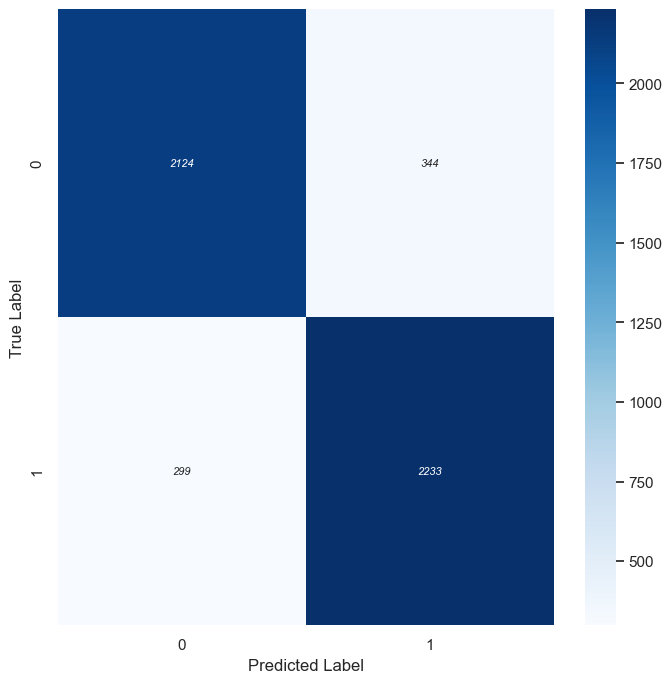

In [14]:
# 모델 예측과 혼동행렬
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pred=model.predict(X_test)
conf_matrix=confusion_matrix(y_test,np.round(pred))

sns.set(style='white')

plt.figure(figsize=(8,8))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d',cbar=True,
            annot_kws={"size": 8, "weight": "normal", "style": "italic"})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

In [4]:
# Embedding 레이어와 CNN 학습모형 
import tensorflow as tf 

# 모델 구성
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=100, input_length=10000),
    # 아래 Conv1D에서 5는 커널 크기, 128은 필터 수 (조절 가능)
    tf.keras.layers.Conv1D(128, 5, activation='relu'),  
    tf.keras.layers.MaxPooling1D(5),  # 풀링 크기 조절 가능
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 모델 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델 훈련
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

# 모델 평가
accuracy = model.evaluate(X_test, y_test)[1]
print(f'Accuracy: {accuracy}')

Epoch 1/5
500/500 [==============================] - 2686s 5s/step - loss: 0.4285 - accuracy: 0.7768 - val_loss: 0.2907 - val_accuracy: 0.8800
Epoch 2/5
500/500 [==============================] - 2635s 5s/step - loss: 0.1734 - accuracy: 0.9364 - val_loss: 0.2812 - val_accuracy: 0.8865
Epoch 3/5
500/500 [==============================] - 2627s 5s/step - loss: 0.0786 - accuracy: 0.9738 - val_loss: 0.3527 - val_accuracy: 0.8808
Epoch 4/5
500/500 [==============================] - 2463s 5s/step - loss: 0.0306 - accuracy: 0.9909 - val_loss: 0.5114 - val_accuracy: 0.8677
Epoch 5/5
157/157 [==============================] - 91s 579ms/step - loss: 0.5393 - accuracy: 0.8878
Accuracy: 0.8877999782562256


# 한글 뉴스 데이터 분석

In [1]:
!git clone https://github.com/e9t/nsmc

Cloning into 'nsmc'...
Updating files:   6% (899/14737)
Updating files:   7% (1032/14737)
Updating files:   8% (1179/14737)
Updating files:   9% (1327/14737)
Updating files:  10% (1474/14737)
Updating files:  11% (1622/14737)
Updating files:  12% (1769/14737)
Updating files:  13% (1916/14737)
Updating files:  14% (2064/14737)
Updating files:  15% (2211/14737)
Updating files:  16% (2358/14737)
Updating files:  16% (2413/14737)
Updating files:  17% (2506/14737)
Updating files:  18% (2653/14737)
Updating files:  19% (2801/14737)
Updating files:  20% (2948/14737)
Updating files:  21% (3095/14737)
Updating files:  22% (3243/14737)
Updating files:  23% (3390/14737)
Updating files:  24% (3537/14737)
Updating files:  25% (3685/14737)
Updating files:  26% (3832/14737)
Updating files:  27% (3979/14737)
Updating files:  27% (4020/14737)
Updating files:  28% (4127/14737)
Updating files:  29% (4274/14737)
Updating files:  30% (4422/14737)
Updating files:  31% (4569/14737)
Updating files:  32% (4716

In [7]:
import pandas as pd 
df=pd.read_table('nsmc/ratings.txt')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        200000 non-null  int64 
 1   document  199992 non-null  object
 2   label     200000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.6+ MB


In [8]:
df.document.iloc[0], df.label.iloc[0]

('어릴때보고 지금다시봐도 재밌어요ㅋㅋ', 1)

In [14]:
from transformers import PreTrainedTokenizer



ParseError: not well-formed (invalid token): line 46, column 41 (<string>)